In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

df['불량여부'] = (df['result'] == '불량').astype(int)

X = df[sensor_cols]
y = df['불량여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('학습용:', X_train.shape[0], '건, 불량', int(y_train.sum()), '건')
print('시험용:', X_test.shape[0], '건, 불량', int(y_test.sum()), '건')

학습용: 1253 건, 불량 83 건
시험용: 314 건, 불량 21 건


# 실습 12: 한 번 잰 점수를 믿어도 되나
- 상황: 재현율을 올렸는데, 그 점수는 한 번 나눠서 잰 것이다
- 목표: 여러 번 나눠 재고, 평균과 흔들림을 함께 적는다

## Step 0. 앞 실습까지 재현하기

## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 여러 번 재는 말

| 말 | 뜻 |
|---|---|
| 교차검증 | 학습용을 여러 덩어리로 나누고, 돌아가며 한 덩어리씩 시험지로 써서 여러 번 재는 방법 |
| 겹 | 나눈 덩어리 하나. 다섯 겹이면 다섯 번 재게 된다 |
| 평균 | 여러 번 잰 점수의 가운데 값 |
| 흔들림 (표준편차) | 잰 값들이 평균에서 얼마나 벌어져 있나. 클수록 들쭉날쭉하다는 뜻 |
| 층화 | 겹마다 드문 쪽 비율을 원래대로 맞춰 나누는 것. 나눌 때 썼던 그 개념 |

## Step 2. 나누는 방식만 바꿔 다섯 번 재보기

In [2]:
# 필요한 도구들을 불러온다
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, f1_score

# random_state - 무작위로 섞는 방식을 고정하는 번호. 번호가 다르면 다르게 섞인다
for 번호 in [1, 42, 7, 100, 2024]:
    # 같은 데이터를 번호만 바꿔 다시 나눈다
    학습입력, 시험입력, 학습정답, 시험정답 = train_test_split(
        X, y, test_size=0.2, random_state=번호, stratify=y)

    # 모델도 설정도 완전히 같다. 바뀐 것은 나눈 방식뿐이다
    모델 = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, class_weight="balanced"))
    모델.fit(학습입력, 학습정답)
    예측 = 모델.predict(시험입력)

    print(f"번호 {번호}: 정확도 {round((예측 == 시험정답).mean() * 100, 2)}%",
          f"재현율 {round(recall_score(시험정답, 예측), 3)}",
          f"F1 {round(f1_score(시험정답, 예측), 3)}")

번호 1: 정확도 78.66% 재현율 0.667 F1 0.295
번호 42: 정확도 74.84% 재현율 0.476 F1 0.202
번호 7: 정확도 73.25% 재현율 0.619 F1 0.236
번호 100: 정확도 78.03% 재현율 0.571 F1 0.258


번호 2024: 정확도 74.2% 재현율 0.619 F1 0.243


## Step 3. 교차검증으로 한 번에 재기

In [3]:
# 교차검증 도구를 불러온다
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# StratifiedKFold - 겹마다 불량 비율을 원래대로 맞춰가며 다섯 덩어리로 나눈다
겹나누기 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

모델 = make_pipeline(StandardScaler(),
                   LogisticRegression(max_iter=1000, class_weight="balanced"))

# 학습용 안에서만 다섯 번 재고 그 점수 다섯 개를 돌려준다. 시험용은 넣지 않는다
점수들 = cross_val_score(모델, X_train, y_train, cv=겹나누기, scoring="recall")

# float(v) - 넘파이 숫자를 파이썬 숫자로 바꾼다. 안 바꾸면 np.float64(0.529) 처럼 이름표가 붙어 나온다
print("겹마다의 재현율:", [round(float(v), 3) for v in 점수들])
print("평균:", round(점수들.mean(), 3))
print("흔들림:", round(점수들.std(), 3))

겹마다의 재현율: [0.529, 0.706, 0.588, 0.562, 0.688]
평균: 0.615
흔들림: 0.07


### 문법 노트 - 여러 번 재기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| StratifiedKFold(n_splits=5) | 다섯 덩어리로 나누되 겹마다 불량 비율을 맞춘다 | 그냥 나누면 어떤 겹에 불량이 거의 없을 수 있다 |
| cross_val_score(..., cv=..) | 겹마다 학습하고 채점해서 점수를 모아준다 | 다섯 번 따로 쓸 코드를 한 줄로 줄인다 |
| scoring="recall" | 무엇을 잴지 정한다 | 안 정하면 정확도로 잰다. 우리 문제에선 그게 함정 |
| .std() | 흔들림(표준편차)을 구한다 | 평균만 보면 들쭉날쭉한 걸 놓친다 |
| float(값) | 넘파이 숫자를 평범한 소수로 바꾼다 | 안 바꾸면 목록 안에서 np.float64(0.529)처럼 이름표가 붙어 나온다 |

## Step 4. 세 모델을 같은 방식으로 재기

In [4]:
# cross_validate - cross_val_score와 같은 방식이지만, scoring에 여러 개를 넣으면 한 번에 다 재준다
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier

겹나누기 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Step 3과 같은 나누는 방식

모델들 = {
    '로지스틱 회귀 (기본)': make_pipeline(StandardScaler(), LogisticRegression()),
    '로지스틱 회귀 (balanced)': make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced")),
    '의사결정나무 (balanced)': DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=10, min_samples_leaf=10),
}

결과 = []
for 이름, model in 모델들.items():
    # 학습용(X_train, y_train) 안에서만 다섯 번 나눠 잰다. 시험용은 넣지 않는다
    점수 = cross_validate(model, X_train, y_train, cv=겹나누기, scoring=['recall', 'f1'])
    결과.append({
        '모델': 이름,
        '재현율 평균': round(점수['test_recall'].mean(), 3),
        '재현율 흔들림': round(점수['test_recall'].std(), 3),
        'F1 평균': round(점수['test_f1'].mean(), 3),
        'F1 흔들림': round(점수['test_f1'].std(), 3),
    })

교차검증표 = pd.DataFrame(결과).set_index('모델')
교차검증표

,재현율 평균,재현율 흔들림,F1 평균,F1 흔들림
모델,,,,
로지스틱 회귀 (기본),0.085,0.064,0.127,0.091
로지스틱 회귀 (balanced),0.615,0.070,0.246,0.020
의사결정나무 (balanced),0.362,0.072,0.175,0.032


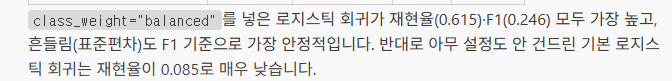

## Step 5. 모델 비교표

| 모델 | 처리 | 설정 | 재현율 (평균 ± 흔들림) | F1 (평균 ± 흔들림) | 시험용 재현율 |
|---|---|---|---|---|---|
| 로지스틱 회귀 | 손 안 댐 | 기본값 | [0.085] ± [0.064] | [0.127] ± [0.091] | [0.095] |
| 로지스틱 회귀 | 가중치 | 기본값 | [0.615] ± [0.070] | [0.246] ± [0.020] | [0.476] |
| 의사결정나무 | 가중치 | [max_depth=10, min_samples_leaf=10] | [0.362] ± [0.072] | [0.175] ± [0.032] | [0.286] |

## Step 6. 오늘 택한 것

- 택한 모델 : [로지스틱 회귀 + 가중치]
- 왜 : [놓친 불량을 줄이는 게 이 공정에서 더 급하다고 봤고, 재현율 평균이 가장 높으면서 흔들림도 작아서]
- 무엇을 내줬나 : [헛경보가 68건으로 늘었다. 정밀도가 0.128까지 내려갔다]
- 아직 못 미더운 점 : [겹에 따라 0.53에서 0.71까지 벌어진다. 시험용에서는 0.476으로 평균보다 낮게 나왔다]

---
## 직접 해보기 (도전) - 몇 겹으로 나눌 것인가

- 상황: 다섯 겹으로 나눴는데, 세 겹이나 열 겹으로 하면 어떻게 될까
- 할 일: 겹 수를 셋·다섯·열로 바꿔가며 평균과 흔들림을 비교한다
- 결과물: 세 줄짜리 표 1개 + 한 줄 메모

In [5]:
# 겹 수만 바꿔가며 같은 모델(표준화 + class_weight="balanced")을 재현율로 교차검증한다 - 학습용만 사용
결과_겹수 = []
for 겹수 in [3, 5, 10]:
    겹나누기_n = StratifiedKFold(n_splits=겹수, shuffle=True, random_state=42)
    모델_n = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=1000, class_weight="balanced"))
    점수들_n = cross_val_score(모델_n, X_train, y_train, cv=겹나누기_n, scoring="recall")

    결과_겹수.append({
        '겹 수': 겹수,
        '겹마다의 점수': [round(float(v), 3) for v in 점수들_n],
        '평균': round(점수들_n.mean(), 3),
        '흔들림': round(점수들_n.std(), 3),
        '겹 하나당 불량 건수(대략)': round(int(y_train.sum()) / 겹수, 1),
    })

겹수_비교표 = pd.DataFrame(결과_겹수).set_index('겹 수')
겹수_비교표

,겹마다의 점수,평균,흔들림,겹 하나당 불량 건수(대략)
겹 수,,,,
3,"[0.5, 0.643, 0.556]",0.566,0.059,27.7
5,"[0.529, 0.706, 0.588, 0.562, 0.688]",0.615,0.070,16.6
10,"[0.778, 0.444, 0.556, 0.875, 0.5, 0.5, 0.625, ...",0.640,0.157,8.3


In [6]:
# 표에서 10겹 목록이 "..."로 잘려 보여서, 겹마다의 점수 목록만 다시 그대로 출력해 확인한다
for 행 in 결과_겹수:
    print(f"겹 {행['겹 수']}:", 행['겹마다의 점수'])

겹 3: [0.5, 0.643, 0.556]
겹 5: [0.529, 0.706, 0.588, 0.562, 0.688]
겹 10: [0.778, 0.444, 0.556, 0.875, 0.5, 0.5, 0.625, 0.75, 0.875, 0.5]


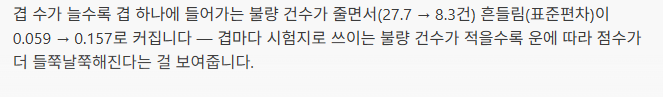

### 겹 수를 바꾸면

| 겹 수 | 평균 | 흔들림 | 겹당 불량 건수 |
|---|---|---|---|
| 3 | [0.566] | [0.059] | [약 27건] |
| 5 | [0.615] | [0.070] | [약 16건] |
| 10 | [0.640] | [0.157] | [약 8건] |

- 알게 된 것 : [많이 나눌수록 평균은 조금 오르지만 흔들림이 커진다. 겹 하나에 불량이 여덟 건뿐이면 한 건 차이가 크게 움직인다]